In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
import argparse
import copy
import gc
import json
import os
import pickle
from datetime import datetime
from functools import partial
import random

import numpy as np
import psutil
import torch
from torch import nn
from tqdm import tqdm

import matplotlib.pyplot as plt

from bioplnn.models import SpatiallyEmbeddedClassifier
from bioplnn.utils import (
    initialize_dataloader,
    initialize_scheduler,
    manual_seed,
)

cabc_data_path = "/om2/user/jackking/torch-bioplnn-dev/data/easy"
checkpoint_path = "/om2/user/jackking/torch-bioplnn-dev/train/checkpoints"
dataset = "cabc"

# Torch setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("high")

BATCH_SIZE = 32

In [21]:
def load_data(dataset, **args):
    train_loader, test_loader = initialize_dataloader(
        seed=42, dataset=dataset, **args
    )
    return train_loader, test_loader

In [22]:
train_loader, test_loader = load_data(dataset, batch_size=BATCH_SIZE, root=cabc_data_path)

In [23]:
trainset = train_loader.dataset

In [25]:
trainset[0][0].shape

torch.Size([1, 350, 350])

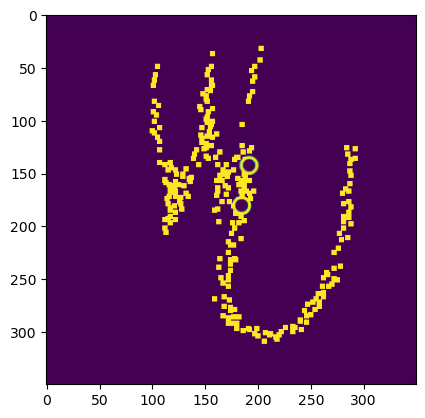

1


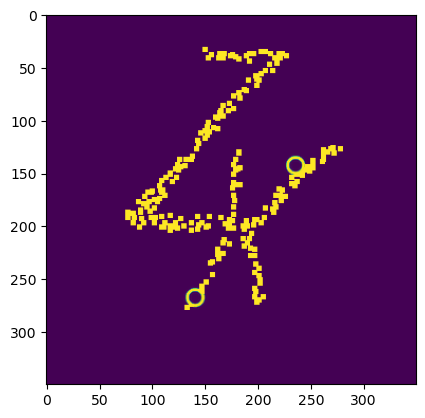

1


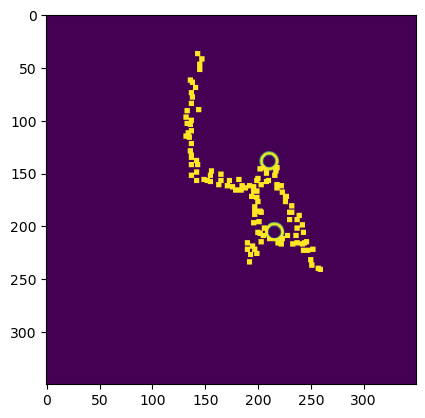

1


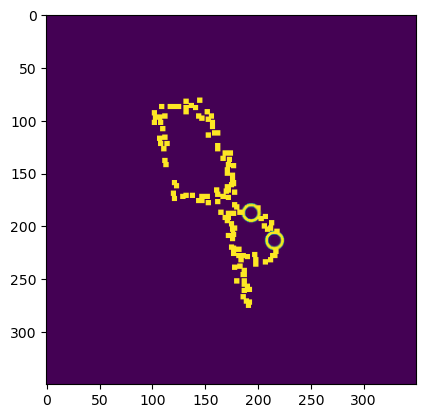

1


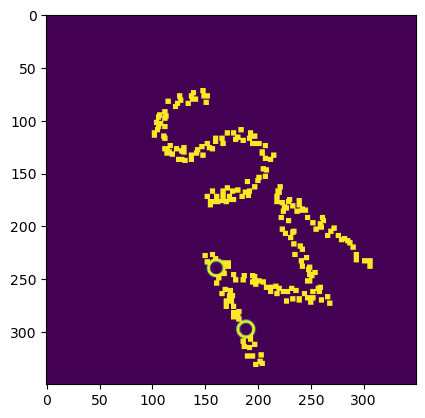

1


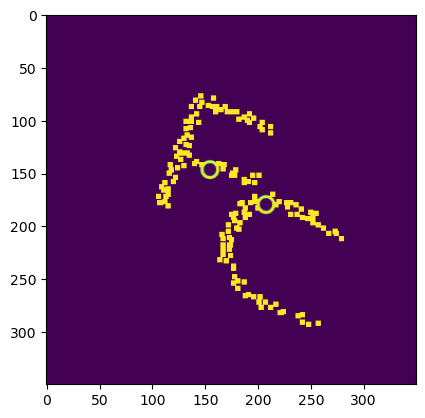

0


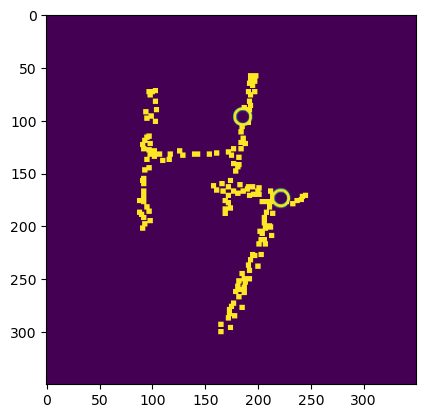

0


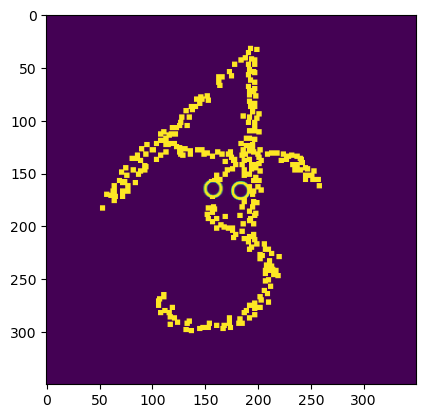

0


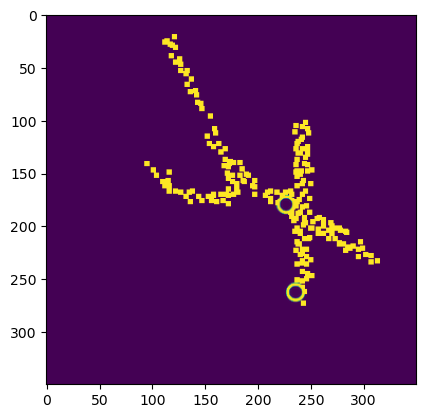

1


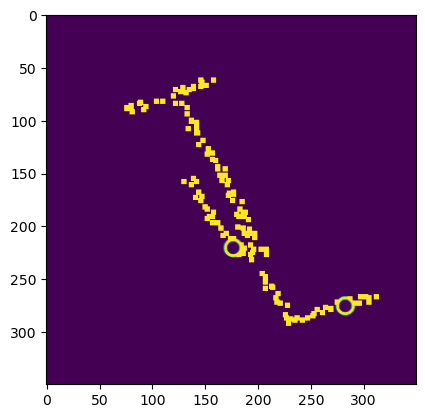

1


In [35]:
for idx in range(10):
    plt.imshow(trainset[idx][0][0])
    plt.show()
    print(trainset[idx][1])